# Proyek Akhir: Menyelesaikan Permasalahan Departemen HR (Attrition Analysis)

- Nama: Moh Asrori
- Email: irvanea1@gmail.com
- Id Dicoding: azzror

## Persiapan

### Menyiapkan library yang dibutuhkan

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style untuk visualisasi
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

### Analisis Variabel Target (Attrition)

ATTRITION DISTRIBUTION
Attrition
0.0    879
1.0    179
Name: count, dtype: int64

Attrition Rate (%)
Attrition
0.0    83.081285
1.0    16.918715
Name: proportion, dtype: float64



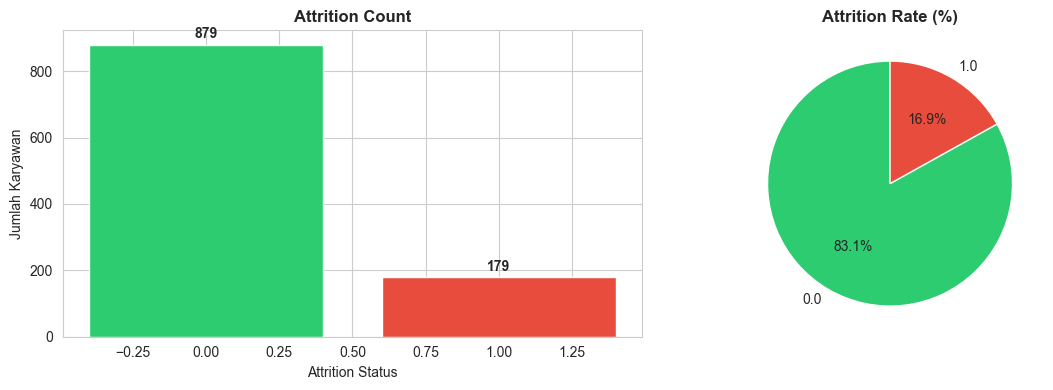


Attrition Rate Perusahaan: 12.18%


In [10]:
# Load dataset
df = pd.read_csv('../employee_data.csv')

# Analisis Attrition
print("=" * 80)
print("ATTRITION DISTRIBUTION")
print("=" * 80)
print(df['Attrition'].value_counts())
print()
print("Attrition Rate (%)")
print(df['Attrition'].value_counts(normalize=True) * 100)
print()

# Visualisasi distribusi attrition
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
attrition_counts = df['Attrition'].value_counts()
axes[0].bar(attrition_counts.index, attrition_counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Attrition Count', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Jumlah Karyawan')
axes[0].set_xlabel('Attrition Status')
for i, v in enumerate(attrition_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

# Pie chart
attrition_pct = df['Attrition'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[1].pie(attrition_pct.values, labels=attrition_pct.index, autopct='%1.1f%%', 
            colors=colors, startangle=90)
axes[1].set_title('Attrition Rate (%)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nAttrition Rate Perusahaan: {(df['Attrition'].value_counts()[1] / len(df)) * 100:.2f}%")

## Data Understanding

### Ringkasan Dataset

Pada bagian ini kami akan memahami struktur data, tipe data, dan karakteristik umum dataset karyawan.

In [11]:
# Tampilkan informasi dasar
print("=" * 80)
print("DATASET SHAPE")
print("=" * 80)
print(f"Jumlah baris: {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")
print()

print("=" * 80)
print("FIRST 5 ROWS")
print("=" * 80)
print(df.head())
print()

print("=" * 80)
print("DATA TYPES")
print("=" * 80)
print(df.dtypes)
print()

print("=" * 80)
print("MISSING VALUES")
print("=" * 80)
missing = df.isnull().sum()
if missing.sum() == 0:
    print("Tidak ada missing values")
else:
    print(missing[missing > 0])
print()

print("=" * 80)
print("BASIC STATISTICS")
print("=" * 80)
print(df.describe())

DATASET SHAPE
Jumlah baris: 1470
Jumlah kolom: 35

FIRST 5 ROWS
   EmployeeId  Age  Attrition     BusinessTravel  DailyRate  \
0           1   38        NaN  Travel_Frequently       1444   
1           2   37        1.0      Travel_Rarely       1141   
2           3   51        1.0      Travel_Rarely       1323   
3           4   42        0.0  Travel_Frequently        555   
4           5   40        NaN      Travel_Rarely       1194   

               Department  DistanceFromHome  Education EducationField  \
0         Human Resources                 1          4          Other   
1  Research & Development                11          2        Medical   
2  Research & Development                 4          4  Life Sciences   
3                   Sales                26          3      Marketing   
4  Research & Development                 2          4        Medical   

   EmployeeCount  ...  RelationshipSatisfaction StandardHours  \
0              1  ...                         2      

## Data Preparation / Preprocessing

Pada bagian ini kami akan mempersiapkan data untuk modeling, termasuk handling missing values, encoding kategori, dan normalisasi.

In [20]:
print("--- PREPARING DATA FOR DASHBOARD ---")
# copy data khusus untuk dashboard
df_dash = df.copy()

# Handling Missing Values
df_dash = df_dash.dropna(subset=['Attrition'])

# Mengubah label numerik menjadi kategorikal agar mudah dibaca di Dashboard
satisfaction_map = {1: '1 - Low', 2: '2 - Medium', 3: '3 - High', 4: '4 - Very High'}
wlb_map = {1: '1 - Bad', 2: '2 - Good', 3: '3 - Better', 4: '4 - Best'}

kolom_satisfaction = ['JobSatisfaction', 'EnvironmentSatisfaction', 'RelationshipSatisfaction']
for col in kolom_satisfaction:
    if col in df_dash.columns:
        df_dash[col] = pd.to_numeric(df_dash[col], errors='coerce').map(satisfaction_map)

if 'WorkLifeBalance' in df_dash.columns:
    df_dash['WorkLifeBalance'] = pd.to_numeric(df_dash['WorkLifeBalance'], errors='coerce').map(wlb_map)

# Memastikan Attrition dan OverTime bernilai Yes/No
if 'Attrition' in df_dash.columns:
    df_dash['Attrition'] = df_dash['Attrition'].replace({1: 'Yes', 0: 'No', '1': 'Yes', '0': 'No', True: 'Yes', False: 'No'})

if 'OverTime' in df_dash.columns:
    df_dash['OverTime'] = df_dash['OverTime'].replace({1: 'Yes', 0: 'No', '1': 'Yes', '0': 'No', True: 'Yes', False: 'No', 'true': 'Yes', 'false': 'No'})


# EXPORT DATA BERSIH KE CSV
df_dash.to_csv('employee_data_clean.csv', index=False)

print("Data bersih berlabel teks berhasil diekspor ke 'employee_data_clean.csv'")
print(f"Total data bersih untuk dashboard: {len(df_dash)} baris")
print("------------------------------------")


--- PREPARING DATA FOR DASHBOARD ---
Data bersih berlabel teks berhasil diekspor ke 'employee_data_clean.csv'
Total data bersih untuk dashboard: 1058 baris
------------------------------------


CORRELATION ANALYSIS - NUMERIC FEATURES DENGAN ATTRITION
TotalWorkingYears          -0.177137
Age                        -0.172067
JobLevel                   -0.169201
StockOptionLevel           -0.164228
MonthlyIncome              -0.163600
YearsInCurrentRole         -0.158757
YearsWithCurrManager       -0.155962
JobInvolvement             -0.150196
YearsAtCompany             -0.135134
EnvironmentSatisfaction    -0.132848
JobSatisfaction            -0.091751
DistanceFromHome            0.078074
WorkLifeBalance            -0.059556
RelationshipSatisfaction   -0.053417
DailyRate                  -0.051992
Name: Attrition, dtype: float64



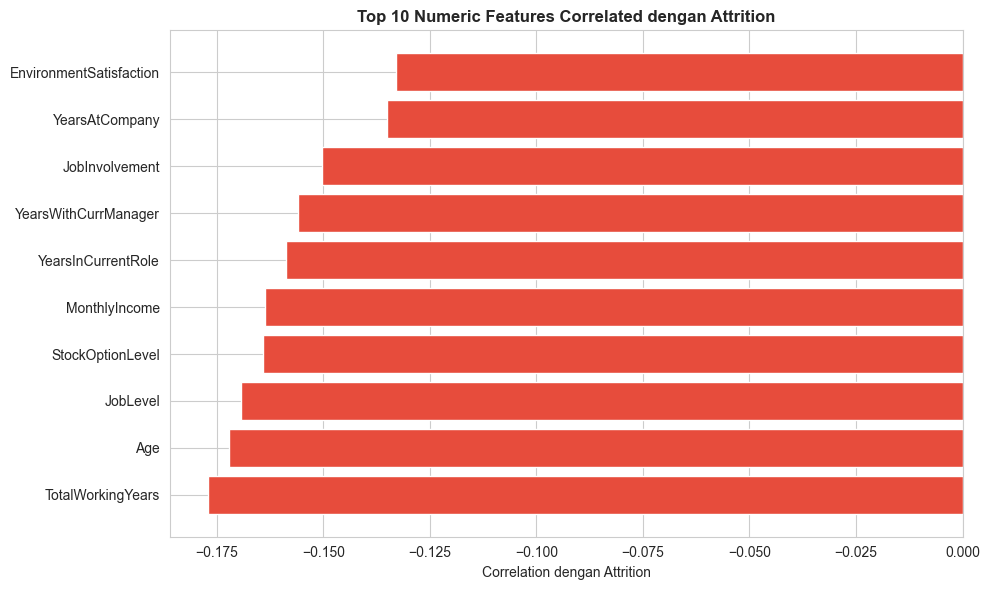

In [15]:
# Identifikasi faktor-faktor attrition
print("=" * 80)
print("CORRELATION ANALYSIS - NUMERIC FEATURES DENGAN ATTRITION")
print("=" * 80)

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove('EmployeeId')  # Hapus EmployeeId
if 'Attrition' in numeric_cols:
    numeric_cols.remove('Attrition')

# Hitung korelasi
correlations = df[numeric_cols + ['Attrition']].corr()['Attrition'].drop('Attrition').sort_values(key=abs, ascending=False)
print(correlations.head(15))
print()

# Visualisasi top 10 korelasi
fig, ax = plt.subplots(figsize=(10, 6))
top_10_corr = correlations.head(10).sort_values()
colors = ['#e74c3c' if x < 0 else '#3498db' for x in top_10_corr.values]
ax.barh(range(len(top_10_corr)), top_10_corr.values, color=colors)
ax.set_yticks(range(len(top_10_corr)))
ax.set_yticklabels(top_10_corr.index)
ax.set_xlabel('Correlation dengan Attrition')
ax.set_title('Top 10 Numeric Features Correlated dengan Attrition', fontweight='bold')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

ATTRITION BY CATEGORICAL FEATURES

Department:
Attrition               0.0  1.0   All
Department                            
Human Resources          32    6    38
Research & Development  594  107   701
Sales                   253   66   319
All                     879  179  1058
Attrition Rate:
Department
Human Resources           15.789474
Research & Development    15.263909
Sales                     20.689655
dtype: float64

JobRole:
Attrition                  0.0  1.0   All
JobRole                                  
Healthcare Representative   80    8    88
Human Resources             24    6    30
Laboratory Technician      139   49   188
Manager                     74    5    79
Manufacturing Director     100    7   107
Research Director           60    2    62
Research Scientist         176   38   214
Sales Executive            193   39   232
Sales Representative        33   25    58
All                        879  179  1058
Attrition Rate:
JobRole
Healthcare Representative     9

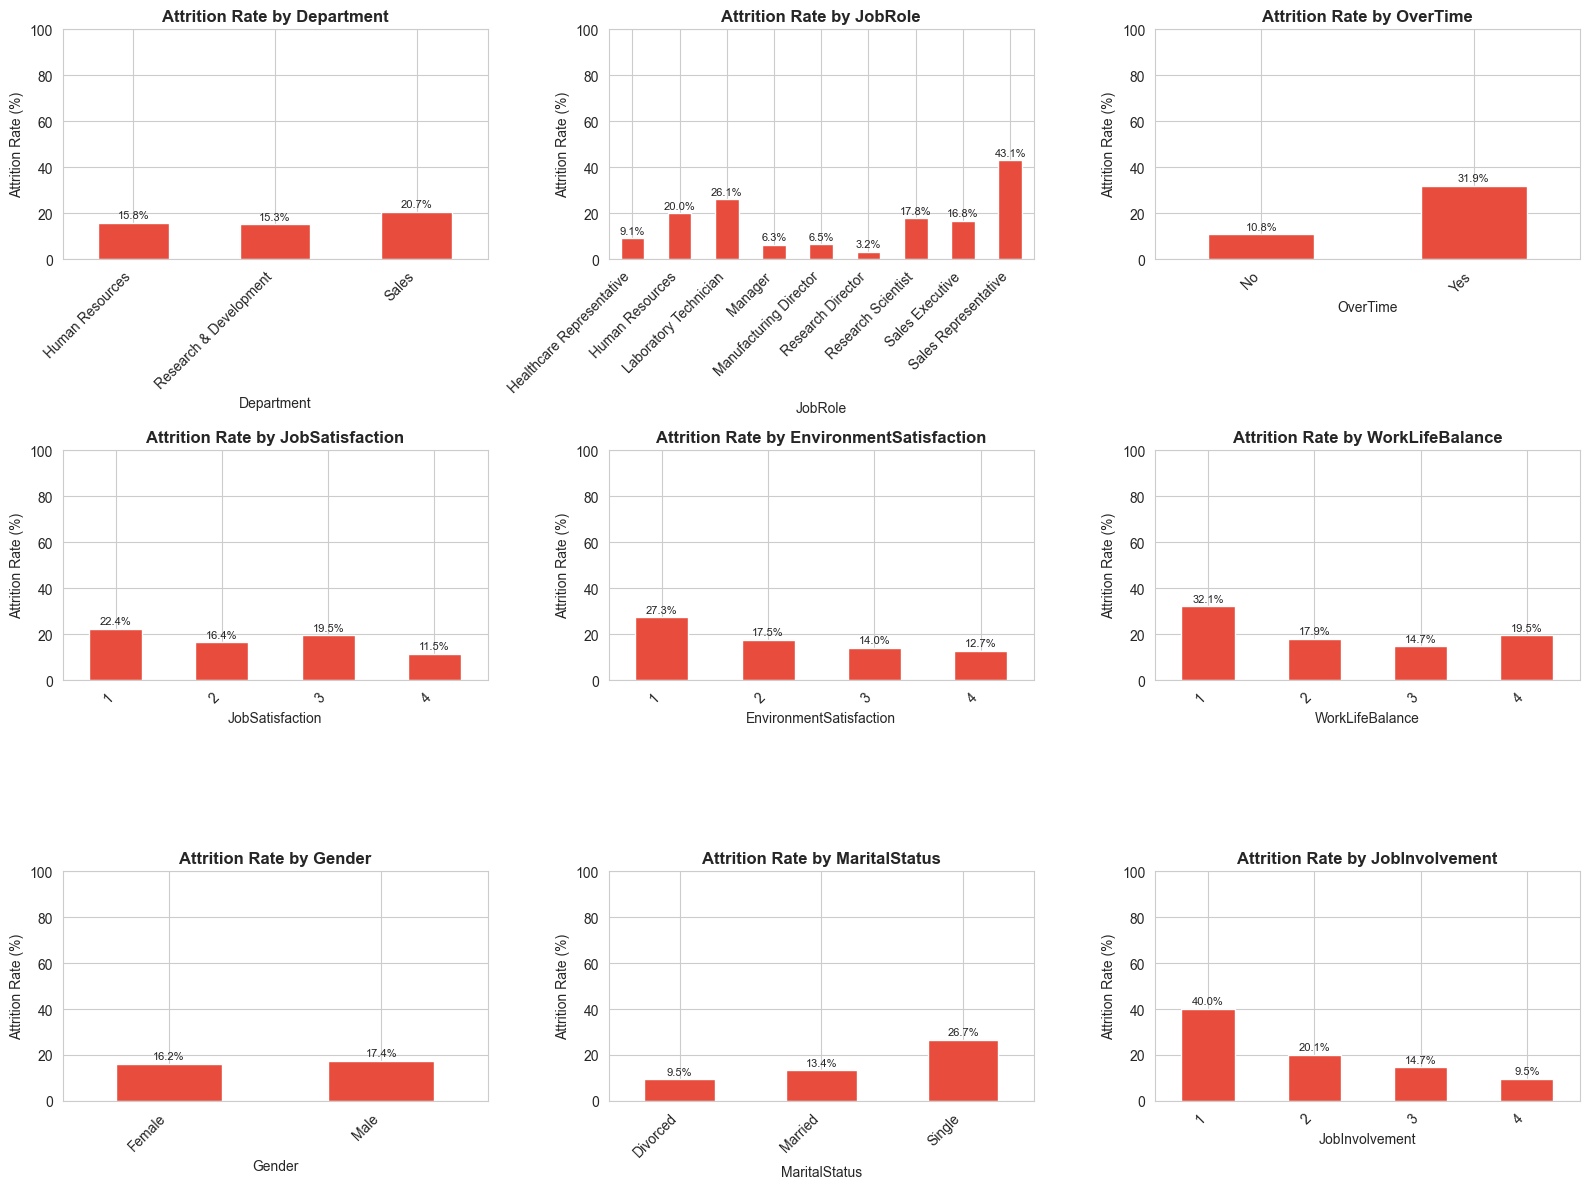

In [16]:
# Analisis Categorical Variables
print("=" * 80)
print("ATTRITION BY CATEGORICAL FEATURES")
print("=" * 80)

categorical_cols = ['Department', 'JobRole', 'OverTime', 'JobSatisfaction', 
                    'EnvironmentSatisfaction', 'WorkLifeBalance', 'Gender', 
                    'MaritalStatus', 'JobInvolvement']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.ravel()

for idx, col in enumerate(categorical_cols):
    if col in df.columns:
        # Count plot dengan attrition
        crosstab = pd.crosstab(df[col], df['Attrition'], margins=True)
        attrition_rate = (crosstab[1.0] / (crosstab[1.0] + crosstab[0.0]) * 100).drop('All', errors='ignore')
        
        ax = axes[idx]
        attrition_rate.plot(kind='bar', ax=ax, color='#e74c3c')
        ax.set_title(f'Attrition Rate by {col}', fontweight='bold')
        ax.set_ylabel('Attrition Rate (%)')
        ax.set_xlabel(col)
        ax.set_ylim(0, 100)
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
        
        # Tambahkan percentage labels
        for i, v in enumerate(attrition_rate):
            ax.text(i, v + 2, f'{v:.1f}%', ha='center', fontsize=8)
        
        print(f"\n{col}:")
        print(crosstab)
        print(f"Attrition Rate:\n{attrition_rate}")

plt.tight_layout()
plt.show()

## Modeling

Pada bagian ini kami akan membangun model machine learning untuk memprediksi attrition. Proses meliputi feature engineering, data splitting, model training, dan evaluasi.

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                             accuracy_score, roc_auc_score, roc_curve, auc)
import joblib

# Persiapan data untuk modeling
df_model = df.copy()

# Encode SEMUA categorical variables terlebih dahulu
label_encoders = {}
categorical_features_all = df_model.select_dtypes(include=['object']).columns.tolist()

for col in categorical_features_all:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    label_encoders[col] = le

# Drop EmployeeId (tidak ada kontribusi prediktif)
if 'EmployeeId' in df_model.columns:
    df_model = df_model.drop('EmployeeId', axis=1)

# Pisahkan features dan target
X = df_model.drop('Attrition', axis=1)
y = df_model['Attrition']

# Handle any remaining NaN values
X = X.fillna(X.mean(numeric_only=True))
y = y.fillna(0)

print("=" * 80)
print("DATA INFO")
print("=" * 80)
print(f"X dtype check:")
print(X.dtypes)
print(f"\nTotal samples: {len(X)}")
print(f"Features: {X.shape[1]}")
print(f"Target distribution:")
print(y.value_counts().sort_index())
print()

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                      random_state=42, stratify=y)

print(f"Train set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")
print()

# Normalisasi fitur  
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("=" * 80)
print("MODEL TRAINING")
print("=" * 80)

# Model 1: Logistic Regression (baseline)
print("\n1. LOGISTIC REGRESSION")
print("-" * 80)
lr_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba_lr):.4f}")
print()

# Model 2: Random Forest
print("2. RANDOM FOREST")
print("-" * 80)
rf_model = RandomForestClassifier(n_estimators=100, max_depth=15, 
                                   random_state=42, class_weight='balanced',
                                   n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba_rf):.4f}")
print()

# Pilih model terbaik
lr_auc = roc_auc_score(y_test, y_pred_proba_lr)
rf_auc = roc_auc_score(y_test, y_pred_proba_rf)

if rf_auc > lr_auc:
    best_model = rf_model
    y_pred = y_pred_rf
    y_pred_proba = y_pred_proba_rf
    model_name = "Random Forest"
else:
    best_model = lr_model
    y_pred = y_pred_lr
    y_pred_proba = y_pred_proba_lr
    model_name = "Logistic Regression"

print(f"Model Terbaik: {model_name}")
print(f"Best ROC-AUC: {max(lr_auc, rf_auc):.4f}")
print()

DATA INFO
X dtype check:
Age                         int64
BusinessTravel              int32
DailyRate                   int64
Department                  int32
DistanceFromHome            int64
Education                   int64
EducationField              int32
EmployeeCount               int64
EnvironmentSatisfaction     int64
Gender                      int32
HourlyRate                  int64
JobInvolvement              int64
JobLevel                    int64
JobRole                     int32
JobSatisfaction             int64
MaritalStatus               int32
MonthlyIncome               int64
MonthlyRate                 int64
NumCompaniesWorked          int64
Over18                      int32
OverTime                    int32
PercentSalaryHike           int64
PerformanceRating           int64
RelationshipSatisfaction    int64
StandardHours               int64
StockOptionLevel            int64
TotalWorkingYears           int64
TrainingTimesLastYear       int64
WorkLifeBalance        

## Evaluation

Pada bagian ini kami mengevaluasi performa model terbaik menggunakan berbagai metrik.

DETAILED MODEL EVALUATION

CLASSIFICATION REPORT
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

No Attrition       0.94      0.73      0.82       176
   Attrition       0.37      0.78      0.50        36

    accuracy                           0.74       212
   macro avg       0.66      0.76      0.66       212
weighted avg       0.85      0.74      0.77       212


CONFUSION MATRIX
--------------------------------------------------------------------------------
[[129  47]
 [  8  28]]



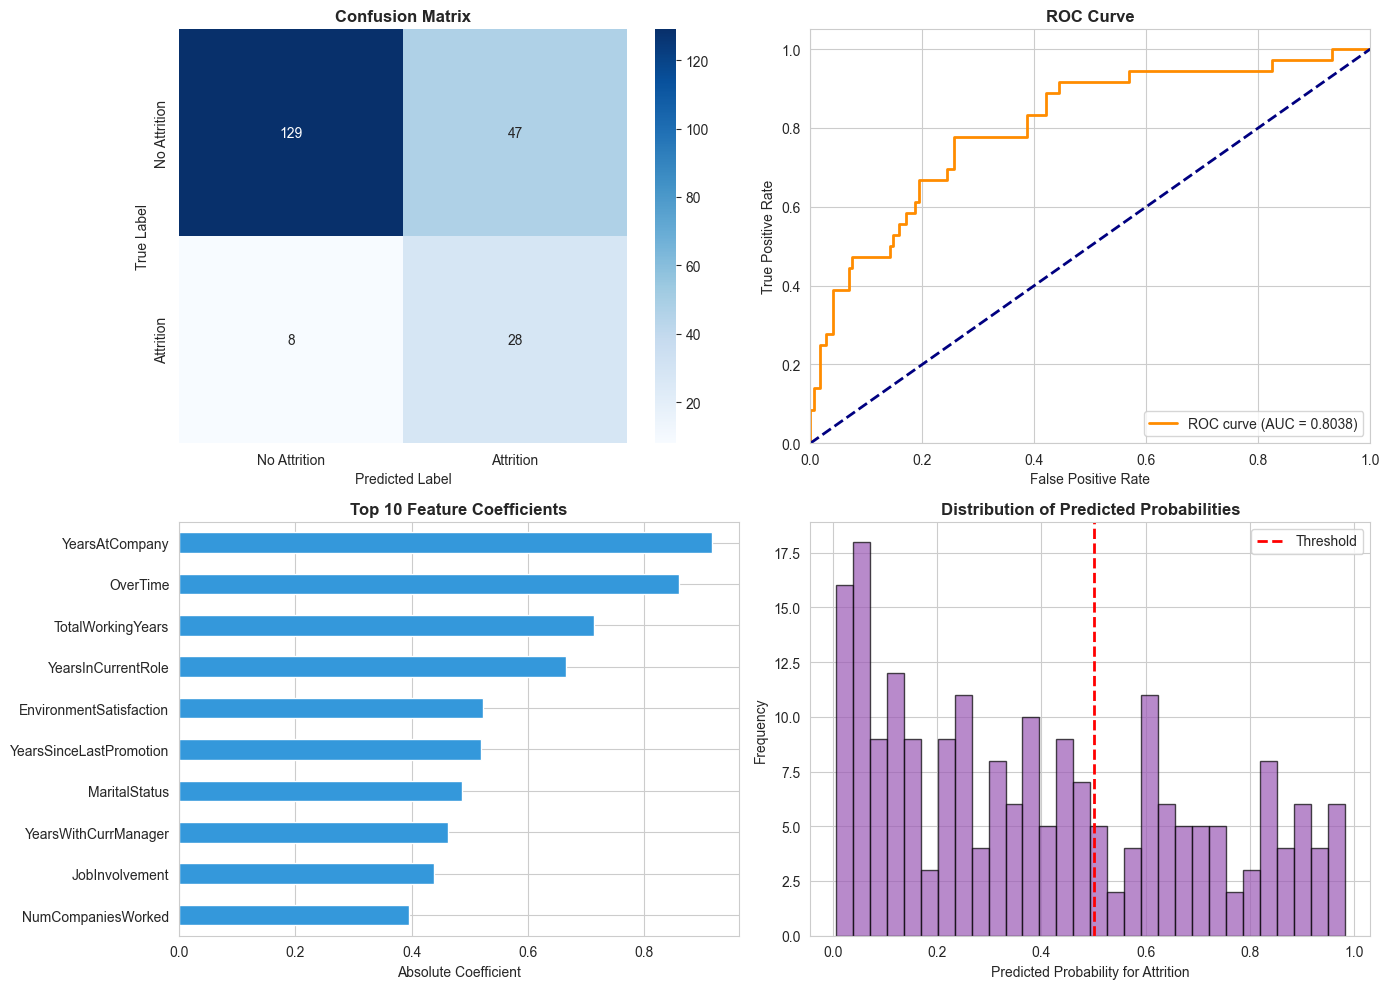

SAVING MODEL

Model, scaler, dan label encoders berhasil disimpan!
Model: ../submission\model/trained_model.pkl
Scaler: ../submission\model/scaler.pkl
Label Encoders: ../submission\model/label_encoders.pkl



In [18]:
print("=" * 80)
print("DETAILED MODEL EVALUATION")
print("=" * 80)
print()

print("CLASSIFICATION REPORT")
print("-" * 80)
print(classification_report(y_test, y_pred, target_names=['No Attrition', 'Attrition']))
print()

print("CONFUSION MATRIX")
print("-" * 80)
cm = confusion_matrix(y_test, y_pred)
print(cm)
print()

# Visualisasi hasil evaluasi
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Confusion matrix heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            xticklabels=['No Attrition', 'Attrition'],
            yticklabels=['No Attrition', 'Attrition'])
axes[0, 0].set_title('Confusion Matrix', fontweight='bold')
axes[0, 0].set_ylabel('True Label')
axes[0, 0].set_xlabel('Predicted Label')

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)
axes[0, 1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[0, 1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0, 1].set_xlim([0.0, 1.0])
axes[0, 1].set_ylim([0.0, 1.05])
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].set_title('ROC Curve', fontweight='bold')
axes[0, 1].legend(loc="lower right")

# Feature Importance (untuk Random Forest)
if model_name == "Random Forest":
    feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
    feature_importance.head(10).plot(kind='barh', ax=axes[1, 0], color='#3498db')
    axes[1, 0].set_title('Top 10 Feature Importance', fontweight='bold')
    axes[1, 0].set_xlabel('Importance')
    axes[1, 0].invert_yaxis()
else:
    # Untuk Logistic Regression
    coef_importance = pd.Series(np.abs(lr_model.coef_[0]), index=X.columns).sort_values(ascending=False)
    coef_importance.head(10).plot(kind='barh', ax=axes[1, 0], color='#3498db')
    axes[1, 0].set_title('Top 10 Feature Coefficients', fontweight='bold')
    axes[1, 0].set_xlabel('Absolute Coefficient')
    axes[1, 0].invert_yaxis()

# Prediction Distribution
axes[1, 1].hist(y_pred_proba, bins=30, edgecolor='black', alpha=0.7, color='#9b59b6')
axes[1, 1].set_xlabel('Predicted Probability for Attrition')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Distribution of Predicted Probabilities', fontweight='bold')
axes[1, 1].axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Threshold')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# Save model
print("=" * 80)
print("SAVING MODEL")
print("=" * 80)
import os

# Buat folder model jika belum ada
if not os.path.exists('../submission\model'):
    os.makedirs('../submission\model')

# Save model
joblib.dump(best_model, '../submission\model/trained_model.pkl')
joblib.dump(scaler, '../submission\model/scaler.pkl')
joblib.dump(label_encoders, '../submission\model/label_encoders.pkl')

print("\nModel, scaler, dan label encoders berhasil disimpan!")
print(f"Model: ../submission\model/trained_model.pkl")
print(f"Scaler: ../submission\model/scaler.pkl")
print(f"Label Encoders: ../submission\model/label_encoders.pkl")
print()